# ch221 — Integration Intuition

If differentiation is about instantaneous rates of change, integration is about accumulation over an interval. The integral of a rate is a total. Distance is the integral of velocity. Area is the integral of height.

The central idea: chop the interval into many thin pieces, sum up the contributions of each piece, take the limit as the pieces shrink to zero.

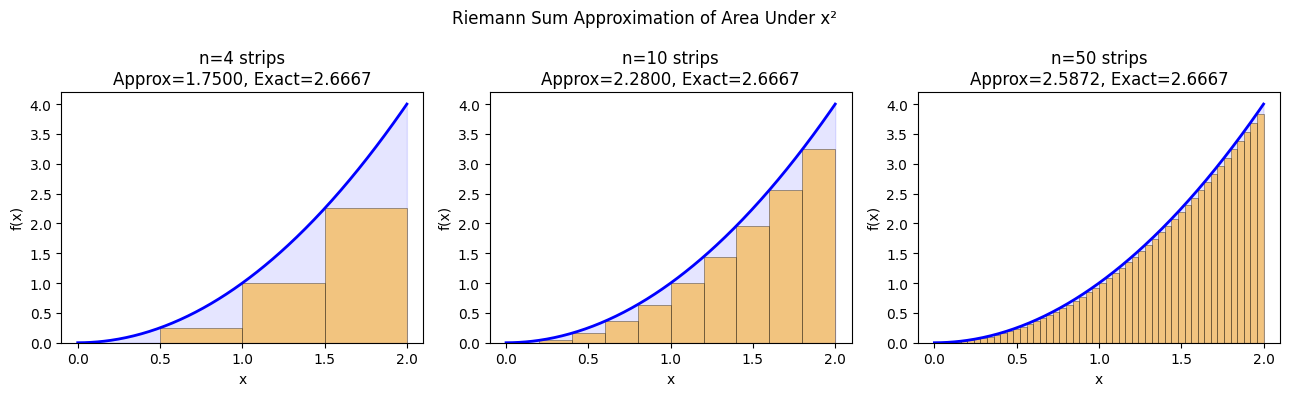

Exact integral: 2.666667


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Visual: approximating the area under f(x) = x^2 from 0 to 2
# True integral = [x^3/3] from 0 to 2 = 8/3 ≈ 2.667

def f(x): return x**2

a, b = 0, 2
exact = b**3/3 - a**3/3

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
x_smooth = np.linspace(a, b, 300)

for ax, n in zip(axes, [4, 10, 50]):
    x_bars = np.linspace(a, b, n+1)
    heights = f(x_bars[:-1])  # left Riemann sum
    width = (b - a) / n
    approx = np.sum(heights) * width

    ax.fill_between(x_smooth, f(x_smooth), alpha=0.1, color='blue')
    ax.bar(x_bars[:-1], heights, width=width, align='edge', alpha=0.5,
           color='orange', edgecolor='black', linewidth=0.5)
    ax.plot(x_smooth, f(x_smooth), 'b', lw=2)
    ax.set_title(f'n={n} strips\nApprox={approx:.4f}, Exact={exact:.4f}')
    ax.set_xlabel('x'); ax.set_ylabel('f(x)')

plt.suptitle('Riemann Sum Approximation of Area Under x²')
plt.tight_layout(); plt.savefig('ch221_riemann.png', dpi=100); plt.show()
print(f"Exact integral: {exact:.6f}")


## The Fundamental Theorem of Calculus

The FTC unifies differentiation and integration — they are inverse operations:

1. If `F'(x) = f(x)`, then the integral of f from a to b equals `F(b) - F(a)`.
2. If `G(x) = integral from a to x of f(t) dt`, then `G'(x) = f(x)`.

This is why the antiderivative is also called the **indefinite integral**.

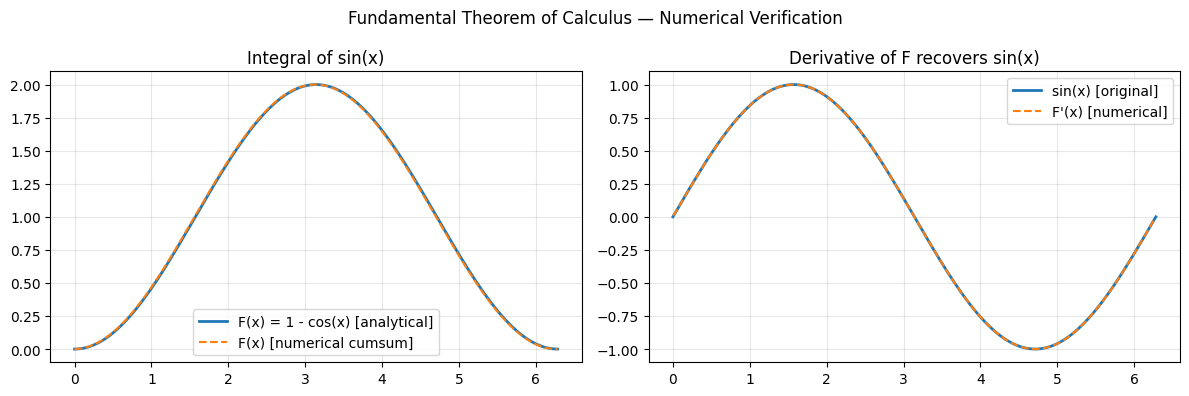

Max error (integral): 0.0105


In [2]:
# Demonstrate FTC numerically: integrate sin(x), get -cos(x)
# F(x) = integral of sin from 0 to x = -cos(x) + cos(0) = 1 - cos(x)

x_vals = np.linspace(0, 2*np.pi, 300)
h = x_vals[1] - x_vals[0]

# Numerical cumulative integral using cumulative sum (left Riemann)
f_vals = np.sin(x_vals)
F_numerical = np.cumsum(f_vals) * h

# Analytical: -cos(x) + 1
F_analytical = 1 - np.cos(x_vals)

# Derivative of F should give back sin(x)
dF_dx_numerical = np.gradient(F_analytical, x_vals)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x_vals, F_analytical, lw=2, label='F(x) = 1 - cos(x) [analytical]')
axes[0].plot(x_vals, F_numerical, '--', lw=1.5, label='F(x) [numerical cumsum]')
axes[0].set_title('Integral of sin(x)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(x_vals, np.sin(x_vals), lw=2, label='sin(x) [original]')
axes[1].plot(x_vals, dF_dx_numerical, '--', lw=1.5, label="F'(x) [numerical]")
axes[1].set_title("Derivative of F recovers sin(x)"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Fundamental Theorem of Calculus — Numerical Verification')
plt.tight_layout(); plt.savefig('ch221_ftc.png', dpi=100); plt.show()
print(f"Max error (integral): {np.max(np.abs(F_numerical - F_analytical)):.4f}")


## Integration as Accumulation

Integration is not just area — it is the general tool for **accumulation**:

| Physical quantity | Rate (derivative) | Accumulated total (integral) |
|---|---|---|
| Distance | Velocity | Position |
| Position | Acceleration | Velocity |
| Revenue | Revenue rate | Total revenue |
| Probability | PDF | CDF |
| Energy | Power | Work |

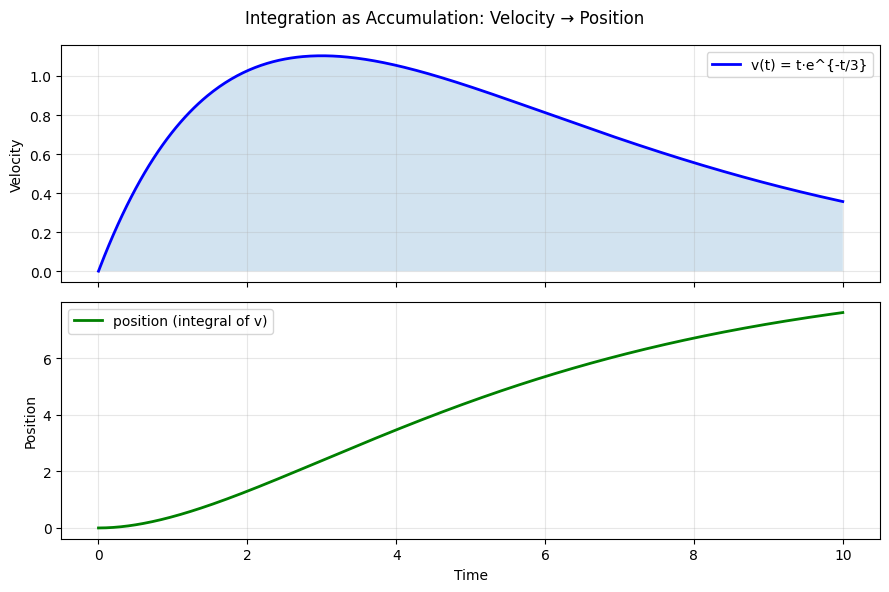

In [3]:
# Real example: position from velocity
# v(t) = t * exp(-t/3)  (accelerates then decelerates)
t = np.linspace(0, 10, 500)
v = t * np.exp(-t/3)

# True position: integral using scipy
from scipy.integrate import cumulative_trapezoid
position = cumulative_trapezoid(v, t, initial=0)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(t, v, color='blue', lw=2, label='v(t) = t·e^{-t/3}')
axes[0].fill_between(t, v, alpha=0.2)
axes[0].set_ylabel('Velocity'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(t, position, color='green', lw=2, label='position (integral of v)')
axes[1].set_ylabel('Position'); axes[1].set_xlabel('Time')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('Integration as Accumulation: Velocity → Position')
plt.tight_layout(); plt.savefig('ch221_accumulation.png', dpi=100); plt.show()


## Summary

| Concept | Key Idea |
|---|---|
| Riemann sum | Approximate area with rectangles, refine limit |
| FTC part 1 | Evaluate definite integral via antiderivative |
| FTC part 2 | Differentiate a cumulative integral → original function |
| Integration as accumulation | Applies far beyond area: distance, probability, energy |

**Forward reference:** ch222 — Area Under Curve extends to signed areas and probability density functions. ch223 — Numerical Integration implements efficient algorithms beyond Riemann sums.